# Mini Deep Learning Project

### Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import datasets
import mlflow
from mlflow.tracking import MlflowClient
from mlflow.models import infer_signature

In [3]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
experiment_name = "dl_mnist"
mlflow.set_experiment(experiment_name)

2026/09/15 13:57:39 INFO mlflow.tracking.fluent: Experiment with name 'dl_mnist' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1789460859827, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789460859827, lifecycle_stage='active', name='dl_mnist', tags={}, trace_location=None, workspace='default'>

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [7]:
def log_model(model, model_name, X_train, y_train):
    # Log the model to MLflow
    mlflow.pytorch.log_model(model, model_name)
    
    # Log the input and output signatures
    signature = infer_signature(X_train, y_train)
    mlflow.log_param("signature", signature)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),

])

train_dataset = torchvision.datasets.MNIST(
    root="./dataset",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./dataset",
    train=False,
    download=True,
    transform=transform
)

train_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loaders = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

torch.Size([128, 1, 28, 28])


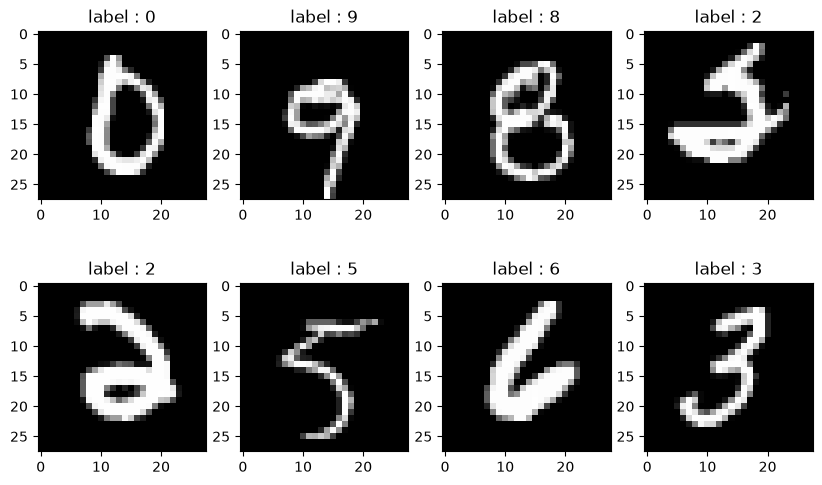

In [6]:
images,lables = next(iter(train_loaders))
print(images.shape)
plt.figure(figsize=(10,6))
for i in range(8):
    image = images[i]
    image = image.permute(1,2,0)
    label = lables[i]
    plt.subplot(2,4,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(f"label : {label}")
    

In [14]:
class MLP_MNIST(nn.Module):
    def __init__(self,hidden=16):
        super().__init__()

        self.mlp_stack = nn.Sequential(
        nn.Linear(784,  hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU(),
        nn.Linear(hidden, 10)
        )
        
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        return self.mlp_stack(x)

model = MLP_MNIST().to(device)

In [15]:
nums_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [17]:
params = {
    "hidden": 16,
    "lr": 0.001,
    "epochs": 10,
    "batch_size": 64,
    "optimizer": "Adam",
}

model = MLP_MNIST(hidden=params['hidden'])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=params["lr"])

In [37]:
def set_mlflow_run():
    mlflow.start_run(run_name=f"mlp_h{params['hidden']}_adam")
    mlflow.log_params(params)

In [22]:
def train_loop(model, train_loader, criterion, optimizer):
  model.train()

  running_loss = 0
  correct = 0
  total = 0

  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # Prediction
    logits = model(images)

    # Compute the loss
    loss = criterion(logits,labels)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()

    # Weight update
    optimizer.step()

    running_loss += loss.item()

    predictions = torch.argmax(logits,dim = 1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

  epoch_loss = running_loss / len(train_loader)
  epoch_acc = correct / total

  print(f"Train Loss : {epoch_loss:.4f} | Train Acc : {epoch_acc:.4f}")
  return epoch_loss, epoch_acc


In [38]:
mlflow.end_run()
set_mlflow_run()
for epoch in range(params["epochs"]):
    print(mlflow.active_run().info.run_name)
    print(f"Epoch : {epoch+1}")
    train_loss, train_acc = train_loop(model, train_loaders, criterion, optimizer)

    mlflow.log_metrics({
            "train_loss": train_loss,
            "train_acc": train_acc,
        }, step=epoch)
mlflow.pytorch.log_model(model, "model")
mlflow.end_run()

mlp_h16_adam
Epoch : 1
Train Loss : 0.1471 | Train Acc : 0.9555
mlp_h16_adam
Epoch : 2
Train Loss : 0.1459 | Train Acc : 0.9561
mlp_h16_adam
Epoch : 3
Train Loss : 0.1447 | Train Acc : 0.9562
mlp_h16_adam
Epoch : 4
Train Loss : 0.1449 | Train Acc : 0.9555
mlp_h16_adam
Epoch : 5
Train Loss : 0.1432 | Train Acc : 0.9560
mlp_h16_adam
Epoch : 6
Train Loss : 0.1426 | Train Acc : 0.9571
mlp_h16_adam
Epoch : 7
Train Loss : 0.1423 | Train Acc : 0.9563
mlp_h16_adam
Epoch : 8
Train Loss : 0.1412 | Train Acc : 0.9568
mlp_h16_adam
Epoch : 9
Train Loss : 0.1423 | Train Acc : 0.9565
mlp_h16_adam
Epoch : 10


2026/09/15 14:36:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 14:36:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Train Loss : 0.1412 | Train Acc : 0.9571
🏃 View run mlp_h16_adam at: http://127.0.0.1:5000/#/experiments/1/runs/17cb2252eeb24e1ea5cba64237555d48
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [40]:
def test_loop(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images,labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            predictions = torch.argmax(logits,dim = 1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    epoch_acc = correct / total
    print(f"Test Acc : {epoch_acc:.4f}")
    return epoch_acc

In [61]:
def run_train_and_test(model, train_loaders, test_loaders, criterion, optimizer, params):
    mlflow.end_run()
    set_mlflow_run()
    run_id = mlflow.active_run().info.run_id
    for epoch in range(params["epochs"]):
        print(f"Epoch : {epoch+1}")
        train_loss, train_acc = train_loop(model, train_loaders, criterion, optimizer)
        test_acc = test_loop(model, test_loaders)

        mlflow.log_metric(f"train_loss_{epoch+1}", train_loss, step=epoch)
        mlflow.log_metric(f"train_acc_{epoch+1}", train_acc, step=epoch)
        mlflow.log_metric(f"test_acc_{epoch+1}", test_acc, step=epoch)

    mlflow.pytorch.log_model(model, "model")
    return run_id


In [52]:
run_train_and_test(model, train_loaders, test_loaders, criterion, optimizer, params)
mlflow.end_run()

Epoch : 1
Train Loss : 0.1254 | Train Acc : 0.9615
Test Acc : 0.9484
Epoch : 2
Train Loss : 0.1244 | Train Acc : 0.9620
Test Acc : 0.9455
Epoch : 3
Train Loss : 0.1245 | Train Acc : 0.9619
Test Acc : 0.9499
Epoch : 4
Train Loss : 0.1238 | Train Acc : 0.9620
Test Acc : 0.9496
Epoch : 5
Train Loss : 0.1231 | Train Acc : 0.9631
Test Acc : 0.9449
Epoch : 6
Train Loss : 0.1225 | Train Acc : 0.9627
Test Acc : 0.9488
Epoch : 7
Train Loss : 0.1237 | Train Acc : 0.9615
Test Acc : 0.9429
Epoch : 8
Train Loss : 0.1239 | Train Acc : 0.9621
Test Acc : 0.9466
Epoch : 9
Train Loss : 0.1235 | Train Acc : 0.9622
Test Acc : 0.9480
Epoch : 10
Train Loss : 0.1239 | Train Acc : 0.9618
Test Acc : 0.9496
🏃 View run mlp_h16_adam at: http://127.0.0.1:5000/#/experiments/1/runs/70aa2602c93b468e856dc5e4cce7c14d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [55]:
class MLP_MNIST_3(nn.Module):
    def __init__(self, p=0.3,hidden=256):
        super().__init__()
        self.mlp_stack = nn.Sequential(
            nn.Linear(784, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.mlp_stack(x)

model3 = MLP_MNIST_3().to(device)

In [62]:
params = {
    "hidden": 256,
    "lr": 0.001,
    "epochs": 10,
    "batch_size": 64,
    "optimizer": "Adam",
    "dropout": 0.3
}

model = MLP_MNIST_3(hidden=params['hidden'], p=params['dropout'])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=params["lr"])

run_train_and_test(model, train_loaders, test_loaders, criterion, optimizer, params)

🏃 View run mlp_h256_adam at: http://127.0.0.1:5000/#/experiments/1/runs/7e67cef05ea64c0b827d6f6d903a423c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Epoch : 1
Train Loss : 0.4811 | Train Acc : 0.8514
Test Acc : 0.9379
Epoch : 2
Train Loss : 0.2366 | Train Acc : 0.9275
Test Acc : 0.9552
Epoch : 3
Train Loss : 0.1895 | Train Acc : 0.9421
Test Acc : 0.9625
Epoch : 4
Train Loss : 0.1673 | Train Acc : 0.9486
Test Acc : 0.9655
Epoch : 5
Train Loss : 0.1473 | Train Acc : 0.9546
Test Acc : 0.9668
Epoch : 6
Train Loss : 0.1383 | Train Acc : 0.9574
Test Acc : 0.9687
Epoch : 7
Train Loss : 0.1293 | Train Acc : 0.9607
Test Acc : 0.9707
Epoch : 8
Train Loss : 0.1235 | Train Acc : 0.9615
Test Acc : 0.9726
Epoch : 9
Train Loss : 0.1128 | Train Acc : 0.9651
Test Acc : 0.9758
Epoch : 10
Train Loss : 0.1121 | Train Acc : 0.9654


2026/09/15 15:09:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 15:09:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Test Acc : 0.9740


'1712adf3a94e406e8f12893c0599b9d2'

In [57]:
mlflow.end_run()

🏃 View run mlp_h256_adam at: http://127.0.0.1:5000/#/experiments/1/runs/fc6ac1602e68490289957d7ced0124a0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [69]:
params = {
    "hidden": 256,
    "lr": 0.001,
    "epochs": 20,
    "batch_size": 128,
    "optimizer": "Adam",
    "dropout": 0.5,
}

model = MLP_MNIST_3(hidden=params["hidden"], p=params["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=params["lr"])

run_id = run_train_and_test(model, train_loaders, test_loaders, criterion, optimizer, params)

Epoch : 1
Train Loss : 0.6434 | Train Acc : 0.7956
Test Acc : 0.9239
Epoch : 2
Train Loss : 0.3557 | Train Acc : 0.8945
Test Acc : 0.9403
Epoch : 3
Train Loss : 0.3020 | Train Acc : 0.9117
Test Acc : 0.9440
Epoch : 4
Train Loss : 0.2704 | Train Acc : 0.9205
Test Acc : 0.9584
Epoch : 5
Train Loss : 0.2515 | Train Acc : 0.9261
Test Acc : 0.9571
Epoch : 6
Train Loss : 0.2354 | Train Acc : 0.9296
Test Acc : 0.9603
Epoch : 7
Train Loss : 0.2244 | Train Acc : 0.9316
Test Acc : 0.9616
Epoch : 8
Train Loss : 0.2175 | Train Acc : 0.9366
Test Acc : 0.9621
Epoch : 9
Train Loss : 0.2086 | Train Acc : 0.9372
Test Acc : 0.9662
Epoch : 10
Train Loss : 0.2072 | Train Acc : 0.9396
Test Acc : 0.9658
Epoch : 11
Train Loss : 0.1986 | Train Acc : 0.9408
Test Acc : 0.9674
Epoch : 12
Train Loss : 0.1958 | Train Acc : 0.9410
Test Acc : 0.9707
Epoch : 13
Train Loss : 0.1888 | Train Acc : 0.9425
Test Acc : 0.9693
Epoch : 14
Train Loss : 0.1839 | Train Acc : 0.9445
Test Acc : 0.9670
Epoch : 15
Train Loss : 0.182

2026/09/15 15:20:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 15:20:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Test Acc : 0.9724


In [70]:
mlflow.end_run()

🏃 View run mlp_h256_adam at: http://127.0.0.1:5000/#/experiments/1/runs/f566c2fe1e0c458e8a3bcafa14003257
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [71]:
mlflow.register_model(f"runs:/{run_id}/model", "mlp_mnist_model")

Registered model 'mlp_mnist_model' already exists. Creating a new version of this model...
2026/09/15 15:20:32 WARNING mlflow.tracking._model_registry.fluent: Run with id f566c2fe1e0c458e8a3bcafa14003257 has no artifacts at artifact path 'model', registering model based on models:/m-155077f76d424629b0fade03facf91ed instead
2026/09/15 15:20:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mlp_mnist_model, version 3
Created version '3' of model 'mlp_mnist_model'.


<ModelVersion: aliases=[], creation_timestamp=1789465832449, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1789465832449, metrics=None, model_id=None, name='mlp_mnist_model', params=None, run_id='f566c2fe1e0c458e8a3bcafa14003257', run_link='', source='models:/m-155077f76d424629b0fade03facf91ed', status='READY', status_message=None, tags={}, user_id='', version='3', workspace='default'>

In [72]:
import torch.nn.functional as F

# Load from the registered model (or use the model object you already have)
loaded = mlflow.pytorch.load_model(f"runs:/{run_id}/model").to(device)
loaded.eval()

# Pick one image from the test set
image, label = test_loaders.dataset[0]     # change index to try others
image = image.unsqueeze(0).to(device)      # add batch dim: (1, 1, 28, 28)

with torch.no_grad():
    logits = loaded(image)
    probs = F.softmax(logits, dim=1)
    pred = probs.argmax(dim=1).item()

print(f"True label : {label}")
print(f"Predicted  : {pred}")
print(f"Confidence : {probs[0, pred]:.4f}")

True label : 7
Predicted  : 7
Confidence : 1.0000


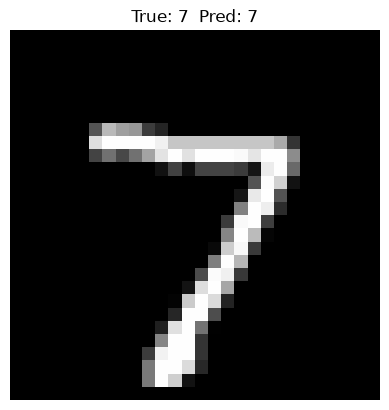

In [73]:
import matplotlib.pyplot as plt
plt.imshow(image.squeeze().cpu(), cmap="gray")
plt.title(f"True: {label}  Pred: {pred}")
plt.axis("off")
plt.show()